# Machine Learning Project

In [18]:
import numpy as np
import pandas as pd
from google.colab import files

In [19]:
df = pd.read_csv("data/placement.csv")


In [20]:
df.head()

,iq,cgpa,placement
0,107,7.2,0
1,112,8.1,1
2,98,6.5,0
3,122,8.7,1
4,115,7.8,1


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   iq         98 non-null     int64  
 1   cgpa       98 non-null     float64
 2   placement  98 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 2.4 KB


In [22]:
df.describe()

,iq,cgpa,placement
count,98.000000,98.000000,98.000000
mean,109.775510,7.415306,0.479592
std,13.930261,0.918128,0.502152
min,79.000000,5.500000,0.000000
25%,99.000000,6.600000,0.000000
50%,108.000000,7.500000,0.000000
75%,120.750000,8.200000,1.000000
max,138.000000,8.900000,1.000000


In [23]:
df.shape

(98, 3)

In [24]:
df.ndim

2

In [25]:
import matplotlib.pyplot as plt



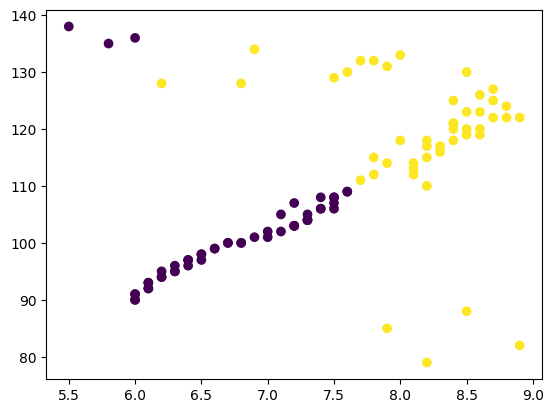

In [26]:
plt.scatter(df["cgpa"], df["iq"], c= df["placement"])

<BarContainer object of 98 artists>

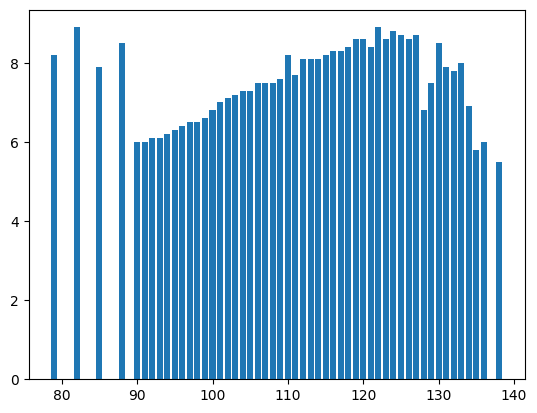

In [30]:
# independent variables -> cgpa, iq
# dependent variables -> placement (depent on cgpa and iq)

x = df.iloc[:, 0:2]
y = df.iloc[:,-1]


In [ ]:
x.shape


(98, 2)

In [33]:
y.shape

(98,)

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test =train_test_split(x, y, test_size=0.10)

In [44]:
X_train

,iq,cgpa
90,95,6.3
78,96,6.4
62,101,6.9
70,100,6.8
12,138,5.5
...,...,...
7,108,7.5
92,104,7.3
56,103,7.2
21,114,7.9


In [47]:
Y_train


,placement
90,0
78,0
62,0
70,0
12,0
...,...
7,0
92,0
56,0
21,1


In [49]:
Y_test.size

10

In [50]:
from sklearn.preprocessing import StandardScaler
 

In [51]:
scaler = StandardScaler()

In [52]:
X_train = scaler.fit_transform(X_train)

In [53]:
X_train

array([[-1.06676334e+00, -1.23492470e+00],
       [-9.95753375e-01, -1.12481997e+00],
       [-6.40703549e-01, -5.74296290e-01],
       [-7.11713514e-01, -6.84401025e-01],
       [ 1.98666516e+00, -2.11576258e+00],
       [-7.11713514e-01, -7.94505761e-01],
       [-7.82723479e-01, -9.04610496e-01],
       [-1.06676334e+00, -1.34502944e+00],
       [-8.53733445e-01, -1.01471523e+00],
       [ 7.08485789e-01,  1.29748421e+00],
       [ 1.34757547e+00,  8.63321220e-02],
       [ 7.79495754e-01,  1.07727474e+00],
       [-1.42181317e+00, -1.56523891e+00],
       [-4.98683619e-01, -2.43982084e-01],
       [ 1.06353561e+00,  1.40758895e+00],
       [ 1.56060537e+00,  3.06541593e-01],
       [-1.13777331e+00, -1.34502944e+00],
       [-6.40703549e-01, -4.64191555e-01],
       [-3.56663689e-01, -3.54086819e-01],
       [-7.82723479e-01, -9.04610496e-01],
       [ 9.21515684e-01,  1.29748421e+00],
       [ 1.27656551e+00, -1.34502944e+00],
       [-1.06676334e+00, -1.23492470e+00],
       [ 6.

In [55]:
X_test = scaler.transform(X_test)
X_test

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-7.89854569, -9.77369466],
       [-7.77248531, -6.98539253],
       [-7.87333361, -9.28877255],
       [-7.79769738, -7.34908411],
       [-7.91367293, -9.89492518],
       [-7.87837603, -9.41000308],
       [-7.77248531, -7.22785358],
       [-7.82290946, -8.1976978 ],
       [-7.77248531, -7.47031464],
       [-7.74727323, -6.864162  ]])

In [56]:
from sklearn.linear_model import LogisticRegression

In [58]:
clf = LogisticRegression()

In [60]:
# Model training
clf.fit(X_train, Y_train)


LogisticRegression()

In [65]:
# evaluate the model
y_pred = clf.predict(X_test)

In [64]:
Y_test

,placement
38,0
95,1
2,0
27,1
9,0
44,0
45,1
40,0
8,1
43,1


In [66]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test, y_pred)

0.5

<Axes: >

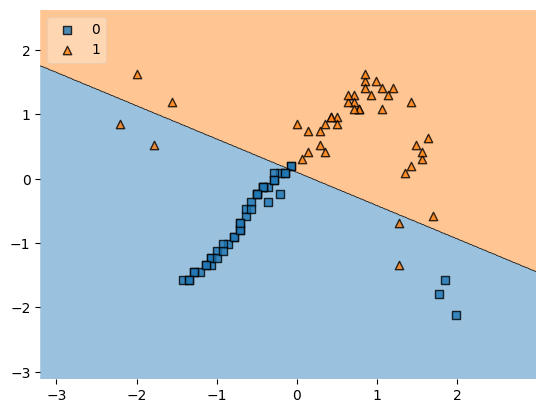

In [67]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train, Y_train.values, clf=clf, legend=2)

In [69]:
import pickle


In [73]:
pickle.dump(clf, open("model.pkl", "wb"))